In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
sns.set(style="white")

In [2]:
data = pd.read_csv('D:\Analytics Vidhya\Projects\synthetic_online_retail_data.csv')

In [3]:
data.head()


,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,17-12-2024,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.0,F,56
1,23188,01-06-2024,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,NaN,M,59
2,55098,04-02-2025,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.0,F,64
3,65208,28-10-2024,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.0,M,34
4,63872,10-05-2024,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.0,F,33


In [4]:
data.tail()

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
995,67967,04-05-2024,965,40,Books & Stationery,Notebook,3,495.24,Cash on Delivery,Hodgemouth,NaN,NaN,30
996,99828,12-09-2024,510,40,Books & Stationery,Story Book,5,427.73,Credit Card,Douglastown,3.0,F,72
997,92290,06-11-2024,445,10,Electronics,Smartphone,5,354.64,Bank Transfer,New Amberville,NaN,M,49
998,61427,17-09-2024,410,10,Electronics,Laptop,4,221.54,Cash on Delivery,New Sean,3.0,M,71
999,20658,06-11-2024,177,40,Books & Stationery,Pen,3,196.97,Cash on Delivery,North Kelsey,1.0,M,34


In [5]:
data.describe()

,customer_id,product_id,category_id,quantity,price,review_score,age
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,799.000000,1000.000000
mean,55490.723000,540.726000,30.030000,2.947000,251.850660,3.992491,46.382000
std,25910.185857,261.737704,14.370303,1.413573,139.194688,1.239469,16.569992
min,10201.000000,100.000000,10.000000,1.000000,10.720000,1.000000,18.000000
25%,33857.000000,311.750000,20.000000,2.000000,128.525000,3.000000,32.000000
50%,54619.500000,542.500000,30.000000,3.000000,250.220000,4.000000,47.000000
75%,77848.500000,770.750000,40.000000,4.000000,366.467500,5.000000,61.000000
max,99923.000000,995.000000,50.000000,5.000000,499.500000,5.000000,75.000000


In [6]:
data.columns


Index(['customer_id', 'order_date', 'product_id', 'category_id',
       'category_name', 'product_name', 'quantity', 'price', 'payment_method',
       'city', 'review_score', 'gender', 'age'],
      dtype='object')

In [7]:
data.shape

(1000, 13)

In [8]:
data.isna().sum()

customer_id         0
order_date          0
product_id          0
category_id         0
category_name       0
product_name        0
quantity            0
price               0
payment_method      0
city                0
review_score      201
gender            103
age                 0
dtype: int64

In [9]:
data['gender'].value_counts()

gender
M    457
F    440
Name: count, dtype: int64

In [10]:
data['review_score'].value_counts()

review_score
5.0    382
4.0    198
3.0    109
1.0     59
2.0     51
Name: count, dtype: int64

In [11]:
rs_mean = data['review_score'].mean()
rs_mean

3.9924906132665834

In [12]:
#data['review_score'].fillna(rs_mean , inplace=True)

In [13]:
data.dtypes

customer_id         int64
order_date         object
product_id          int64
category_id         int64
category_name      object
product_name       object
quantity            int64
price             float64
payment_method     object
city               object
review_score      float64
gender             object
age                 int64
dtype: object

In [14]:
len(data.city.unique())

962

In [15]:
data['order_date'] = data['order_date'].astype('category')
data['product_name'] = data['product_name'].astype('category')
data['city'] = data['city'].astype('category')
data['gender'] = data['gender'].astype('category')
data['payment_method'] = data['payment_method'].astype('category')
data['category_name'] = data['category_name'].astype('category')


In [16]:
data.dtypes

customer_id          int64
order_date        category
product_id           int64
category_id          int64
category_name     category
product_name      category
quantity             int64
price              float64
payment_method    category
city              category
review_score       float64
gender            category
age                  int64
dtype: object

In [17]:
numerical_col = data.select_dtypes(include=['float','int64']).columns
numerical_col

Index(['customer_id', 'product_id', 'category_id', 'quantity', 'price',
       'review_score', 'age'],
      dtype='object')

In [18]:
data[numerical_col].max()

customer_id     99923.0
product_id        995.0
category_id        50.0
quantity            5.0
price             499.5
review_score        5.0
age                75.0
dtype: float64

In [19]:
data[numerical_col].min()

customer_id     10201.00
product_id        100.00
category_id        10.00
quantity            1.00
price              10.72
review_score        1.00
age                18.00
dtype: float64

In [20]:
data.describe(include=['float','int64'])

,customer_id,product_id,category_id,quantity,price,review_score,age
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,799.000000,1000.000000
mean,55490.723000,540.726000,30.030000,2.947000,251.850660,3.992491,46.382000
std,25910.185857,261.737704,14.370303,1.413573,139.194688,1.239469,16.569992
min,10201.000000,100.000000,10.000000,1.000000,10.720000,1.000000,18.000000
25%,33857.000000,311.750000,20.000000,2.000000,128.525000,3.000000,32.000000
50%,54619.500000,542.500000,30.000000,3.000000,250.220000,4.000000,47.000000
75%,77848.500000,770.750000,40.000000,4.000000,366.467500,5.000000,61.000000
max,99923.000000,995.000000,50.000000,5.000000,499.500000,5.000000,75.000000


In [21]:
def outlier(data,var_group):

    for col in var_group:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_high = (data[col] > upper_bound).sum()
        outlier_low  = (data[col] < lower_bound).sum()

        plt.figure(figsize=(6,4))
        sns.boxplot(y=data[col], color="skyblue")
        plt.title(f'Boxplot of {col}')


        plt.figtext(0.15, -0.2, f"column: {col}\nlLower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}\nOutliers Below: {outlier_high}",
                   fontsize=10, ha="left", bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.5"))

plt.show()

In [22]:
outlier(data,numerical_col)

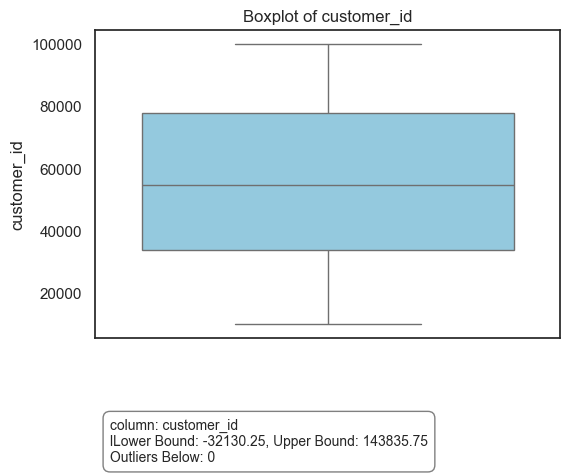

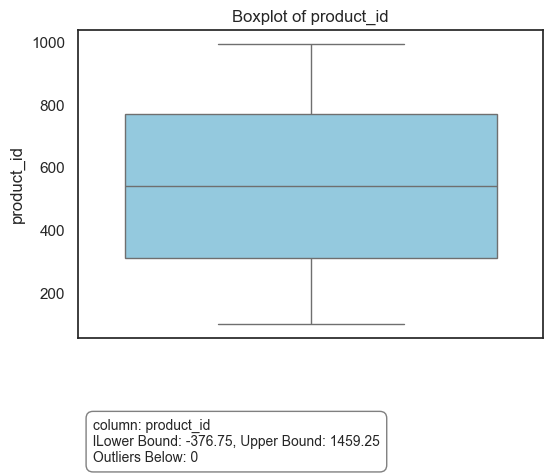

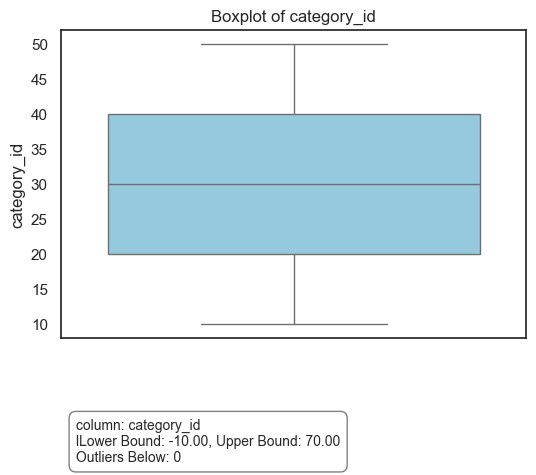

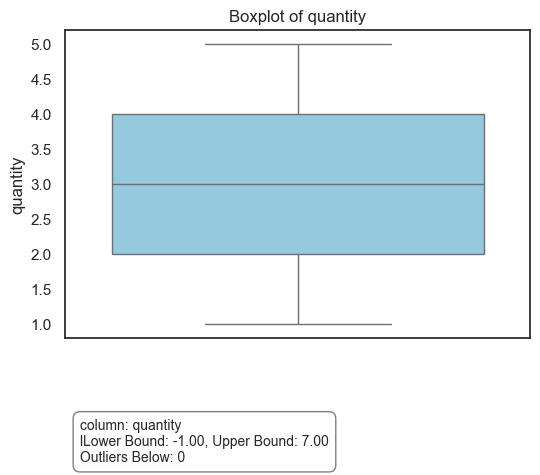

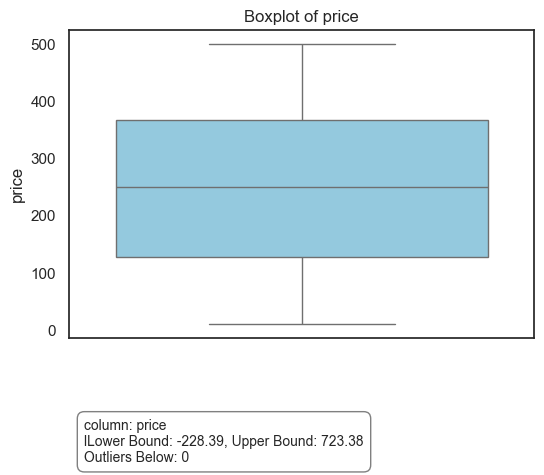

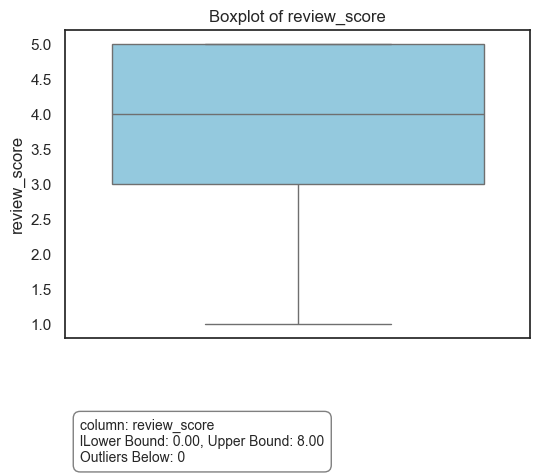

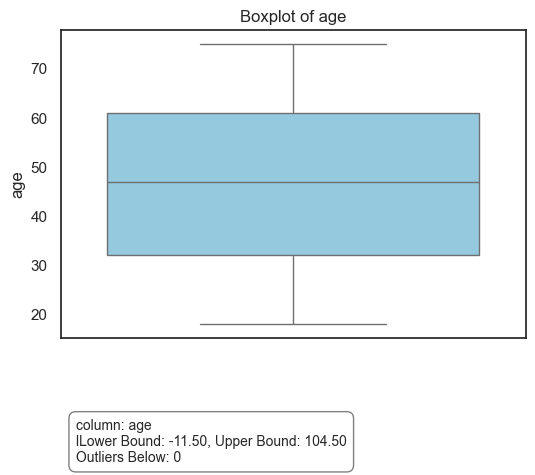

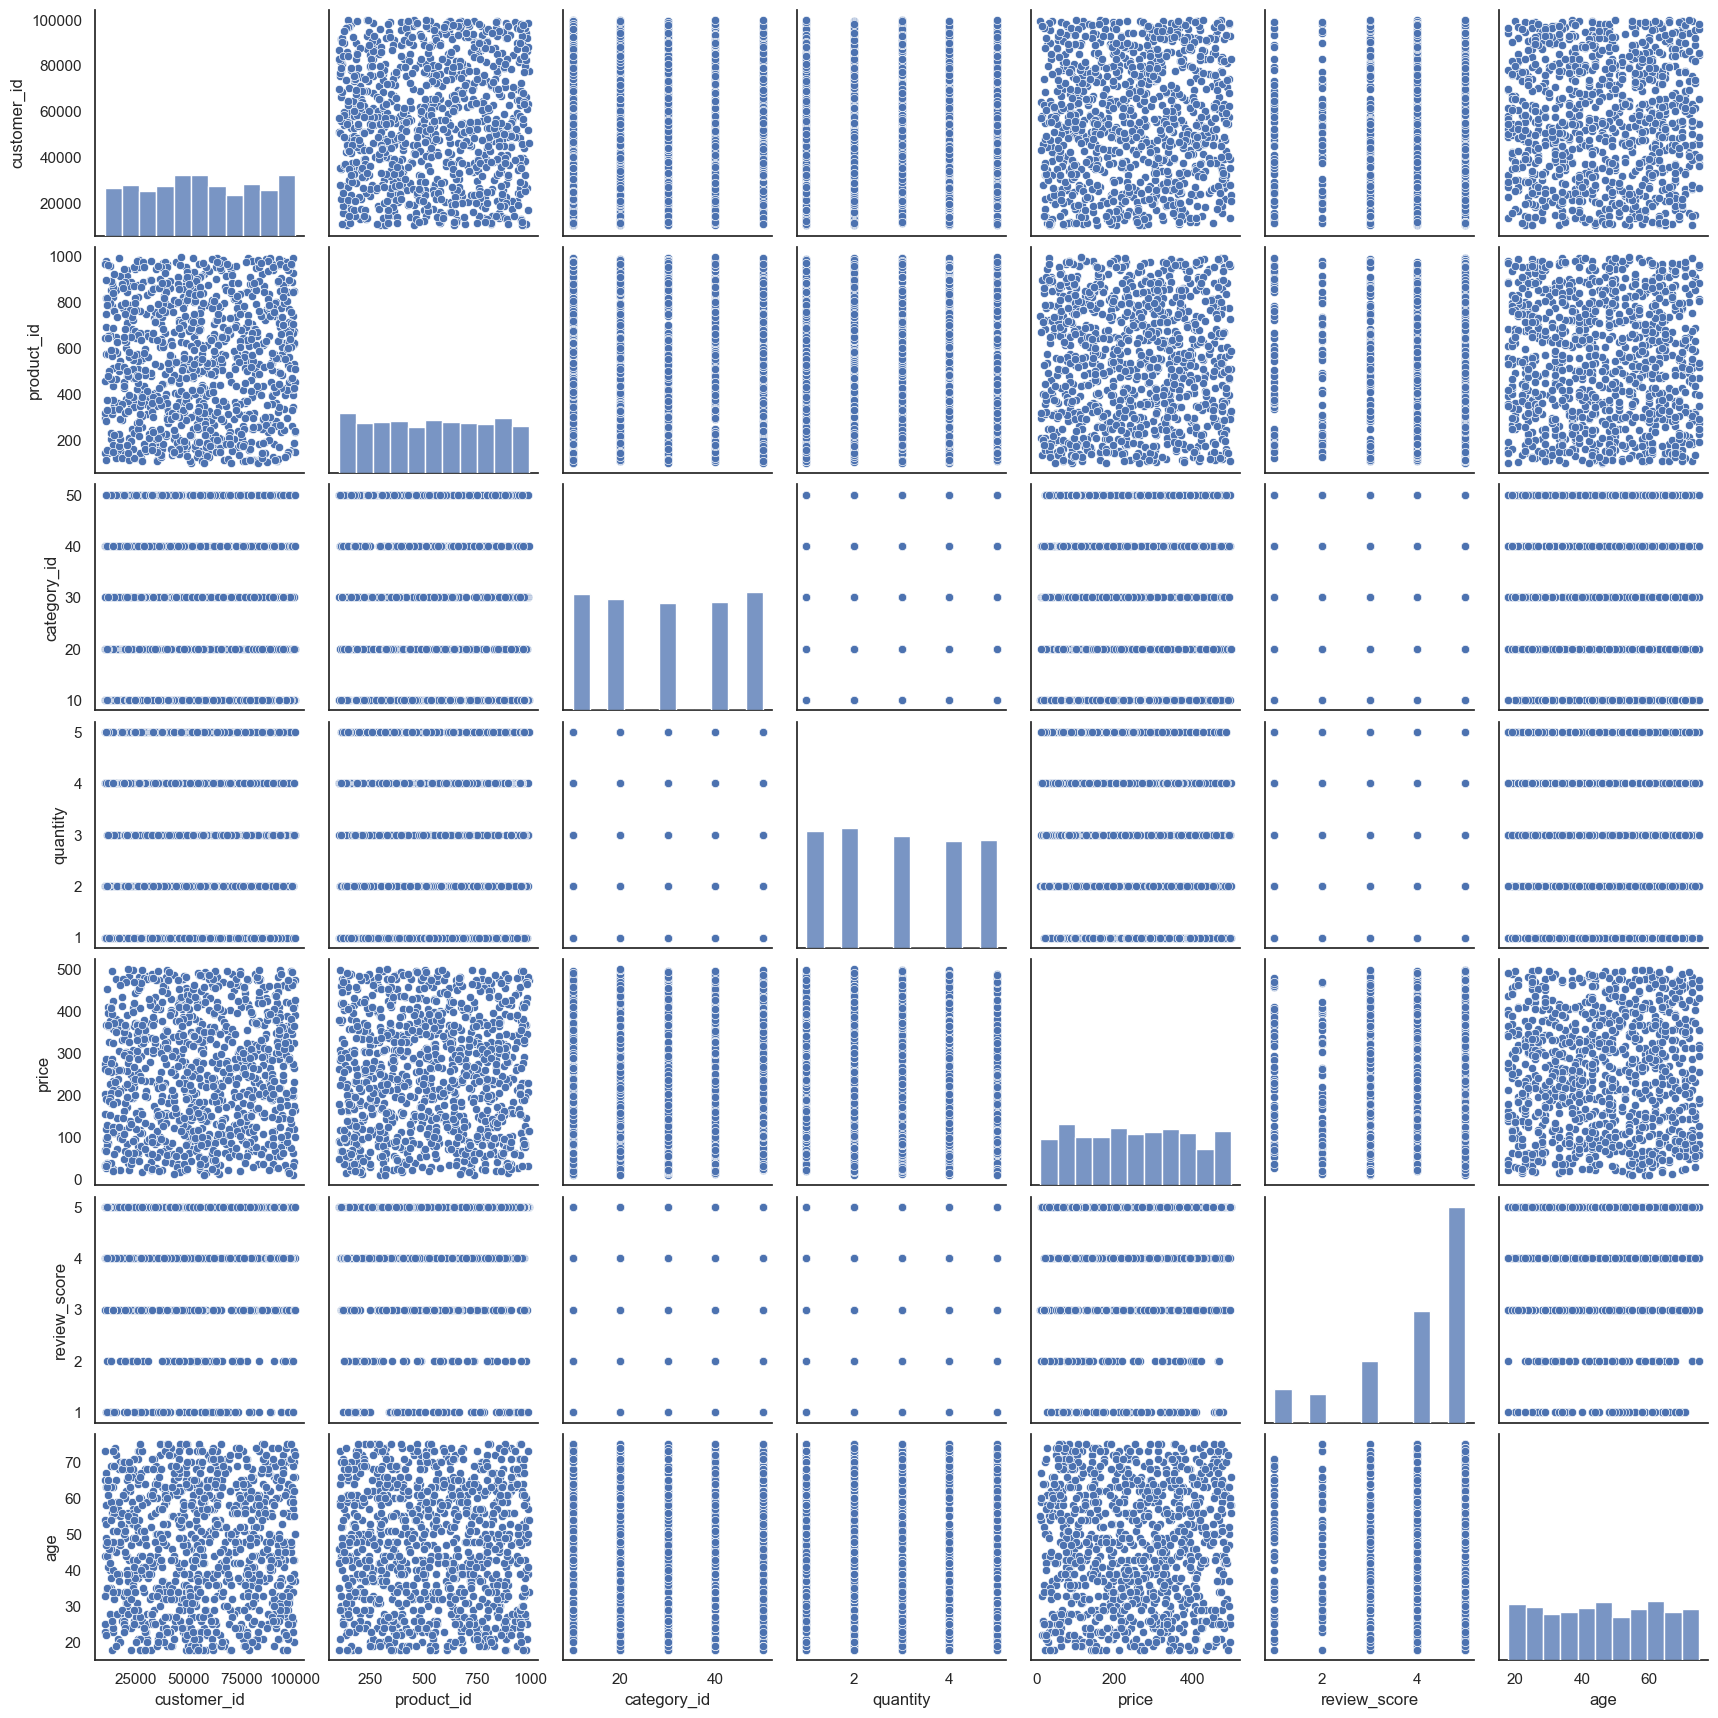

In [23]:
df_numerical_col = data.select_dtypes(include=['float', 'int64'])

sns.pairplot(df_numerical_col)
plt.show()

In [24]:
data['order_date'] = pd.to_datetime(data['order_date'], dayfirst=True)
data['Month'] = data['order_date'].dt.month
data['Year'] = data['order_date'].dt.year

In [25]:
data[['Month','Year']].head()

,Month,Year
0,12,2024
1,6,2024
2,2,2025
3,10,2024
4,5,2024


In [26]:
customer_age = data[['age']]
customer_age

,age
0,56
1,59
2,64
3,34
4,33
...,...
995,30
996,72
997,49
998,71


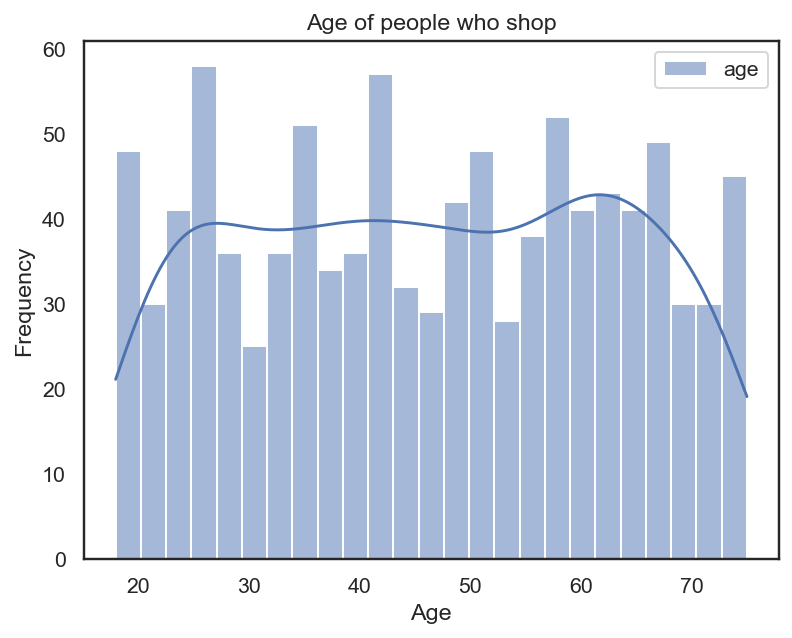

In [27]:
plt.figure(dpi = 140)
sns.histplot(customer_age,bins=25, kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age of people who shop')
plt.show()

In [28]:
data['age'].value_counts()

age
39    24
63    24
68    23
48    23
34    22
61    22
44    22
43    22
65    21
23    21
26    21
50    21
24    20
25    20
29    20
56    20
64    20
57    19
49    19
42    19
60    19
62    19
32    19
59    18
21    18
19    18
18    18
38    18
71    18
55    18
27    17
47    17
73    17
33    17
75    16
41    16
37    16
28    16
69    15
70    15
58    15
54    15
52    15
36    15
35    14
67    13
53    13
66    13
31    13
40    12
72    12
22    12
46    12
51    12
74    12
20    12
30    12
45    10
Name: count, dtype: int64

In [29]:
# Calculate revenue
data['Revenue'] = data['quantity'] * data['price']
data['prd_tol_revenue'] = data.groupby('product_name')['Revenue'].transform('sum')
data['cat_tol_revenue'] = data.groupby('category_name')['Revenue'].transform('sum')
city_revenue = data.groupby('city')['Revenue'].transform('sum')
data['Monthly_Revenue'] = data.groupby('Month')['Revenue'].transform('sum')

In [30]:
data.head(5)

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age,Month,Year,Revenue,prd_tol_revenue,cat_tol_revenue,Monthly_Revenue
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.0,F,56,12,2024,746.72,38319.26,166510.34,78432.94
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,NaN,M,59,6,2024,1496.70,37587.30,154346.26,59127.40
2,55098,2025-02-04,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.0,F,64,2,2025,115.00,23449.52,154346.26,48826.04
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.0,M,34,10,2024,460.22,29062.57,143215.52,55328.98
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.0,F,33,5,2024,706.88,29501.01,134714.61,61448.18


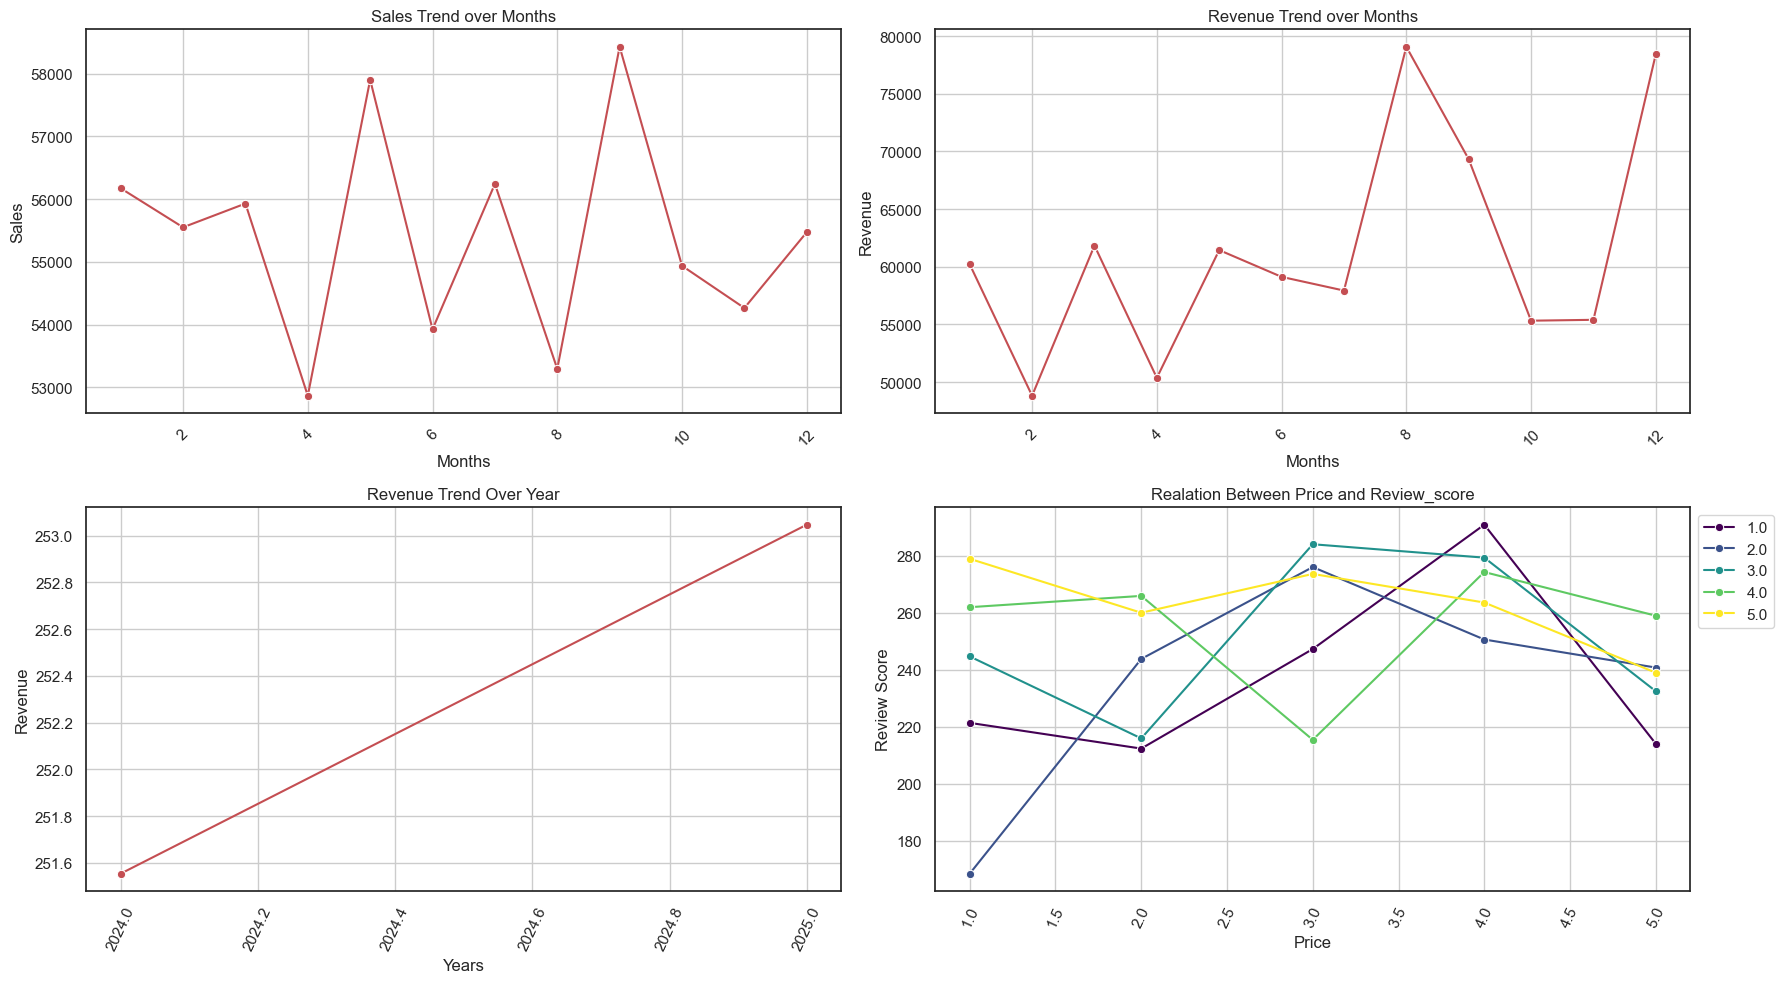

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.lineplot(x='Month', y='customer_id', data=data,  color='r', marker='o', ax=axes[0,0], ci=None)
axes[0,0].set_title('Sales Trend over Months')
axes[0,0].set_xlabel('Months')
axes[0,0].set_ylabel('Sales')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True)

sns.lineplot(x='Month', y='Monthly_Revenue', data=data,  color='r',marker='o',  ax=axes[0,1], ci=None)
axes[0,1].set_title('Revenue Trend over Months')
axes[0,1].set_xlabel('Months')
axes[0,1].set_ylabel('Revenue')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True)

sns.lineplot(x='Year', y='price', data=data, color='r', ax=axes[1,0], marker='o', ci=None)
axes[1,0].set_title('Revenue Trend Over Year')
axes[1,0].set_xlabel('Years')
axes[1,0].set_ylabel('Revenue')
axes[1,0].tick_params(axis='x', rotation=65)
axes[1,0].grid(True)

sns.lineplot(x='quantity', y='price', data=data, hue='review_score' , palette='viridis', ax=axes[1,1], marker='o',ci=None)
axes[1,1].set_title('Realation Between Price and Review_score')
axes[1,1].set_xlabel('Price')
axes[1,1].set_ylabel('Review Score')
axes[1,1].tick_params(axis='x', rotation=65)
axes[1,1].grid(True)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

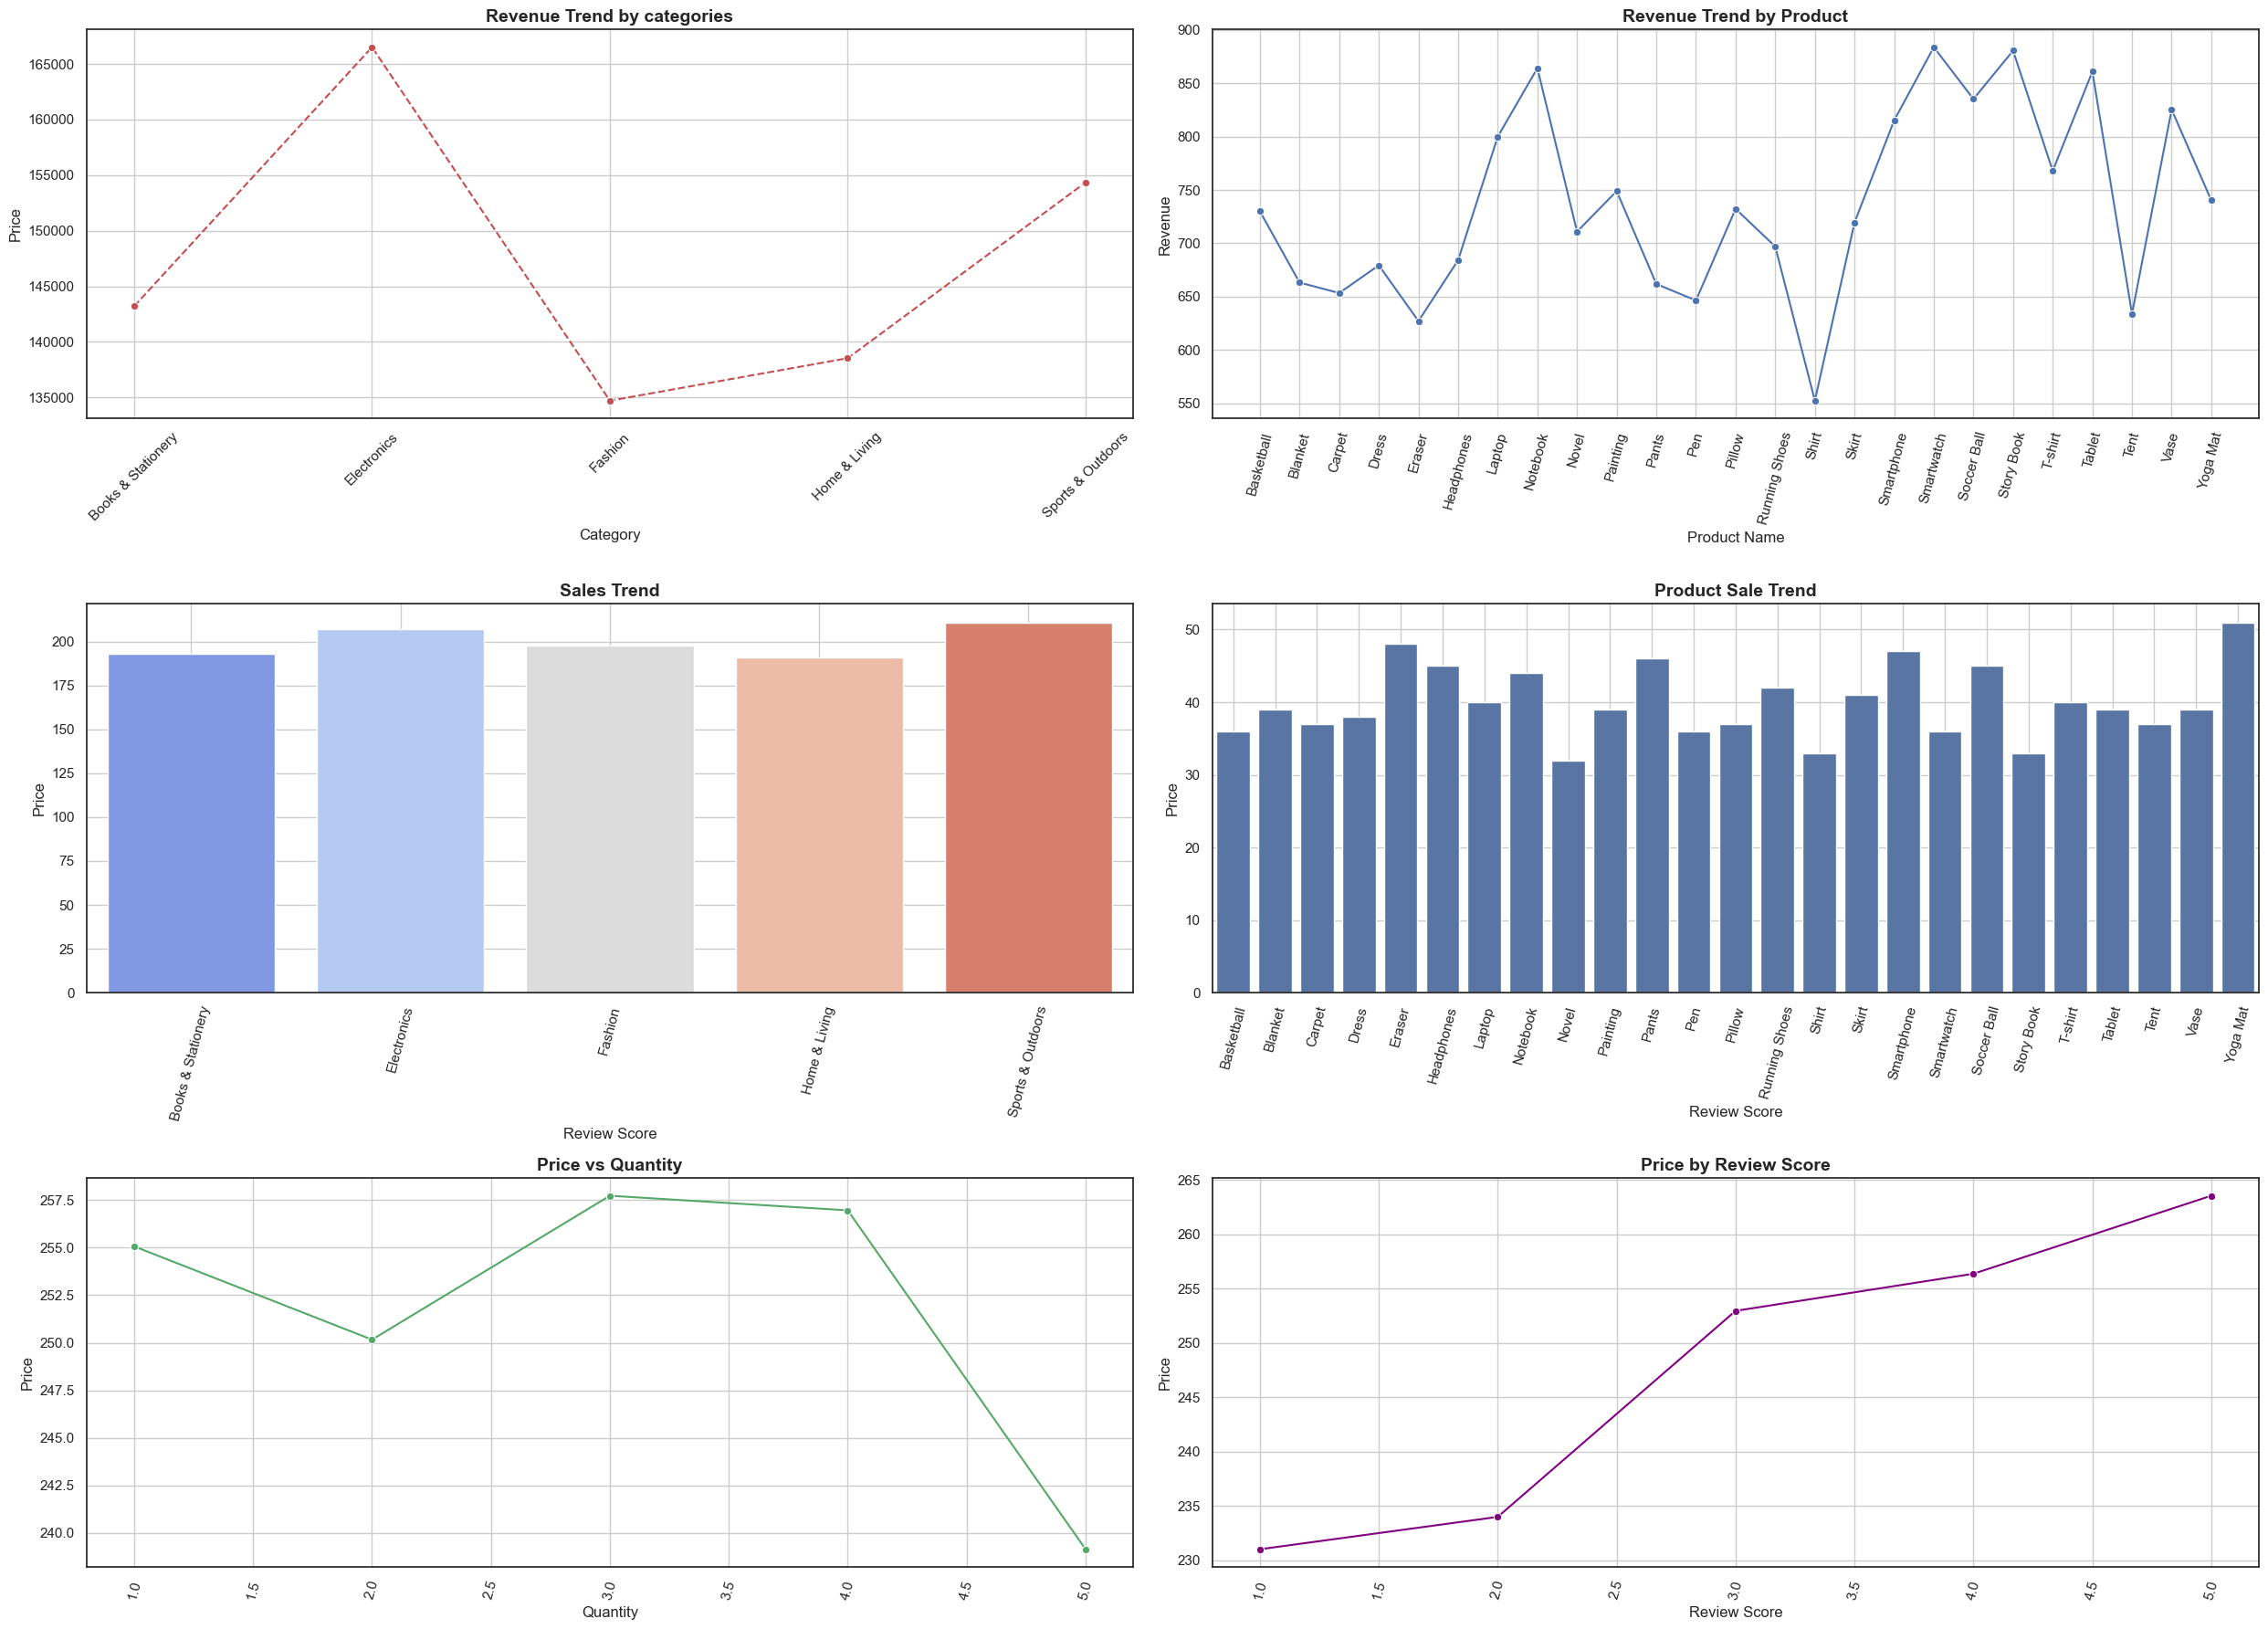

In [32]:
fig, axes = plt.subplots(3, 2, figsize=(25, 18))


sns.lineplot(x='category_name', y='cat_tol_revenue', data=data, color='r', marker='o', ax=axes[0, 0], linestyle='dashed', ci=None)
axes[0, 0].set_title('Revenue Trend by categories', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Category', fontsize=12)
axes[0, 0].set_ylabel('Price', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True)



sns.lineplot(x='product_name', y='Revenue', data=data, color='b', marker='o', ax=axes[0, 1], ci=None)
axes[0, 1].set_title('Revenue Trend by Product', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Product Name', fontsize=12)
axes[0, 1].set_ylabel('Revenue', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=75)
axes[0, 1].grid(True)


sns.countplot(x='category_name',  data=data, palette="coolwarm", ax=axes[1, 0])
axes[1, 0].set_title('Sales Trend', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Review Score', fontsize=12)
axes[1, 0].set_ylabel('Price', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=75)
axes[1, 0].grid(True)



sns.countplot(x='product_name', data=data, ax=axes[1, 1])
axes[1, 1].set_title('Product Sale Trend', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Review Score', fontsize=12)
axes[1, 1].set_ylabel('Price', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=75)
axes[1, 1].grid(True)



sns.lineplot(x='quantity', y='price', data=data, color='g', marker='o', ax=axes[2, 0], ci=None)
axes[2, 0].set_title('Price vs Quantity', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Quantity', fontsize=12)
axes[2, 0].set_ylabel('Price', fontsize=12)
axes[2, 0].tick_params(axis='x', rotation=75)
axes[2, 0].grid(True)



sns.lineplot(x='review_score', y='price', data=data, color='purple', marker='o', ax=axes[2, 1], ci=None)
axes[2, 1].set_title('Price by Review Score', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Review Score', fontsize=12)
axes[2, 1].set_ylabel('Price', fontsize=12)
axes[2, 1].tick_params(axis='x', rotation=75)
axes[2, 1].grid(True)

plt.tight_layout() 
plt.show()

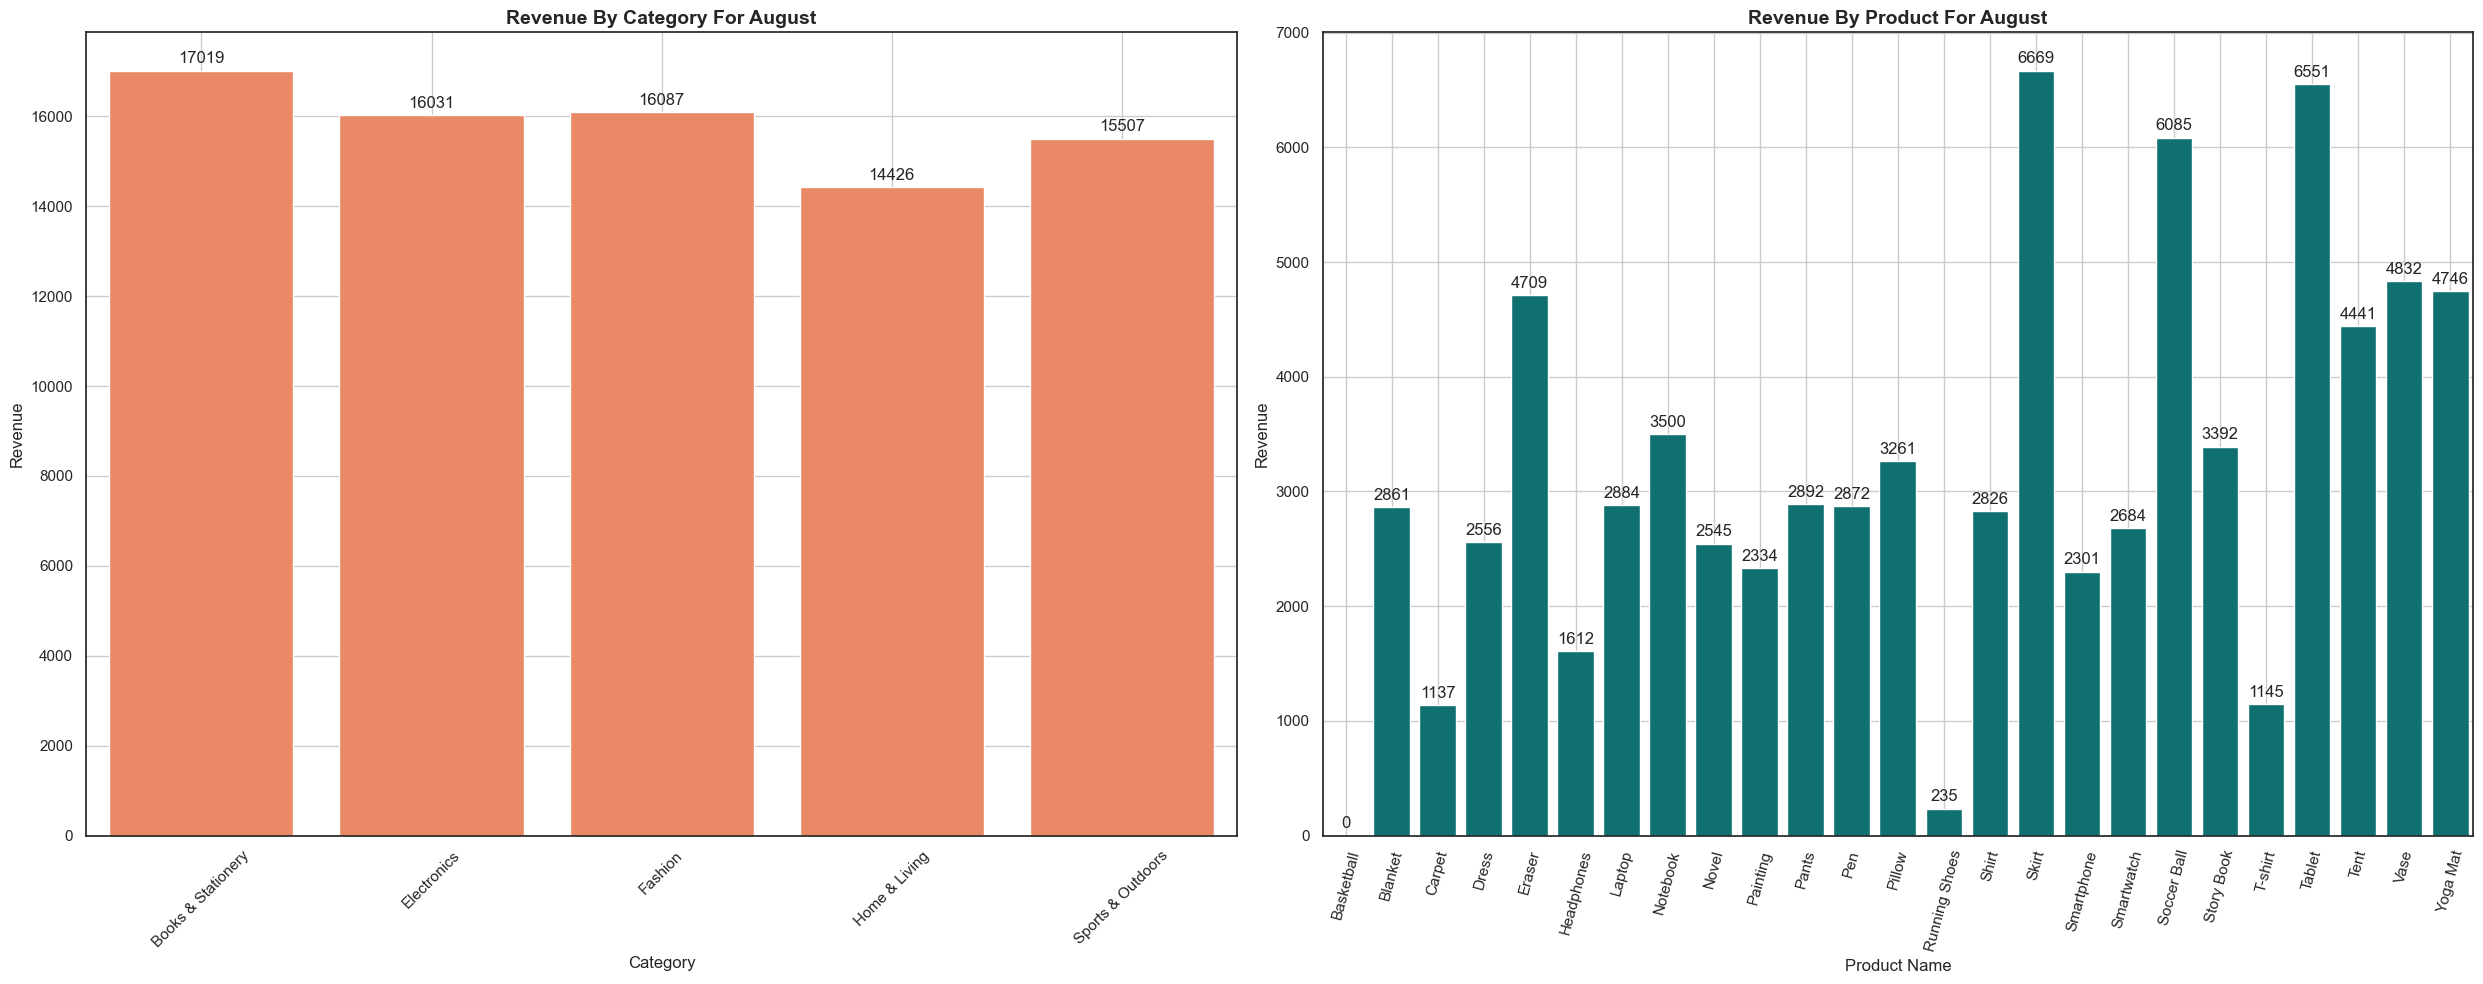

In [39]:
# Filter August data
august_sale = data[data['Month'] == 8]

# Group by category
category_revenue_aug = (
    august_sale.groupby('category_name')['Revenue'].sum()
    .reset_index()
    .rename(columns={'Revenue': 'cat_tol_revenue'})
)

# Group by product
product_revenue_aug = (
    august_sale.groupby('product_name')['Revenue'].sum()
    .reset_index()
    .rename(columns={'Revenue': 'prod_tol_revenue'})
)

# Sort for better visualization
category_revenue_aug = category_revenue_aug.sort_values(by='cat_tol_revenue', ascending=False)
product_revenue_aug = product_revenue_aug.sort_values(by='prod_tol_revenue', ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(25, 10))

# Plot 1: Revenue by Category (Bar)
category_plot = sns.barplot(
    x='category_name', y='cat_tol_revenue',
    data=category_revenue_aug, color='coral', ax=axes[0]
)
axes[0].set_title('Revenue By Category For August', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Revenue', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

# Add value labels on bars
axes[0].bar_label(category_plot.containers[0], fmt='%.0f', label_type='edge', padding=3)

# Plot 2: Revenue by Product (Bar)
product_plot = sns.barplot(
    x='product_name', y='prod_tol_revenue',
    data=product_revenue_aug, color='teal', ax=axes[1]
)
axes[1].set_title('Revenue By Product For August', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Name', fontsize=12)
axes[1].set_ylabel('Revenue', fontsize=12)
axes[1].tick_params(axis='x', rotation=75)
axes[1].grid(True)

# Add value labels on bars
axes[1].bar_label(product_plot.containers[0], fmt='%.0f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()


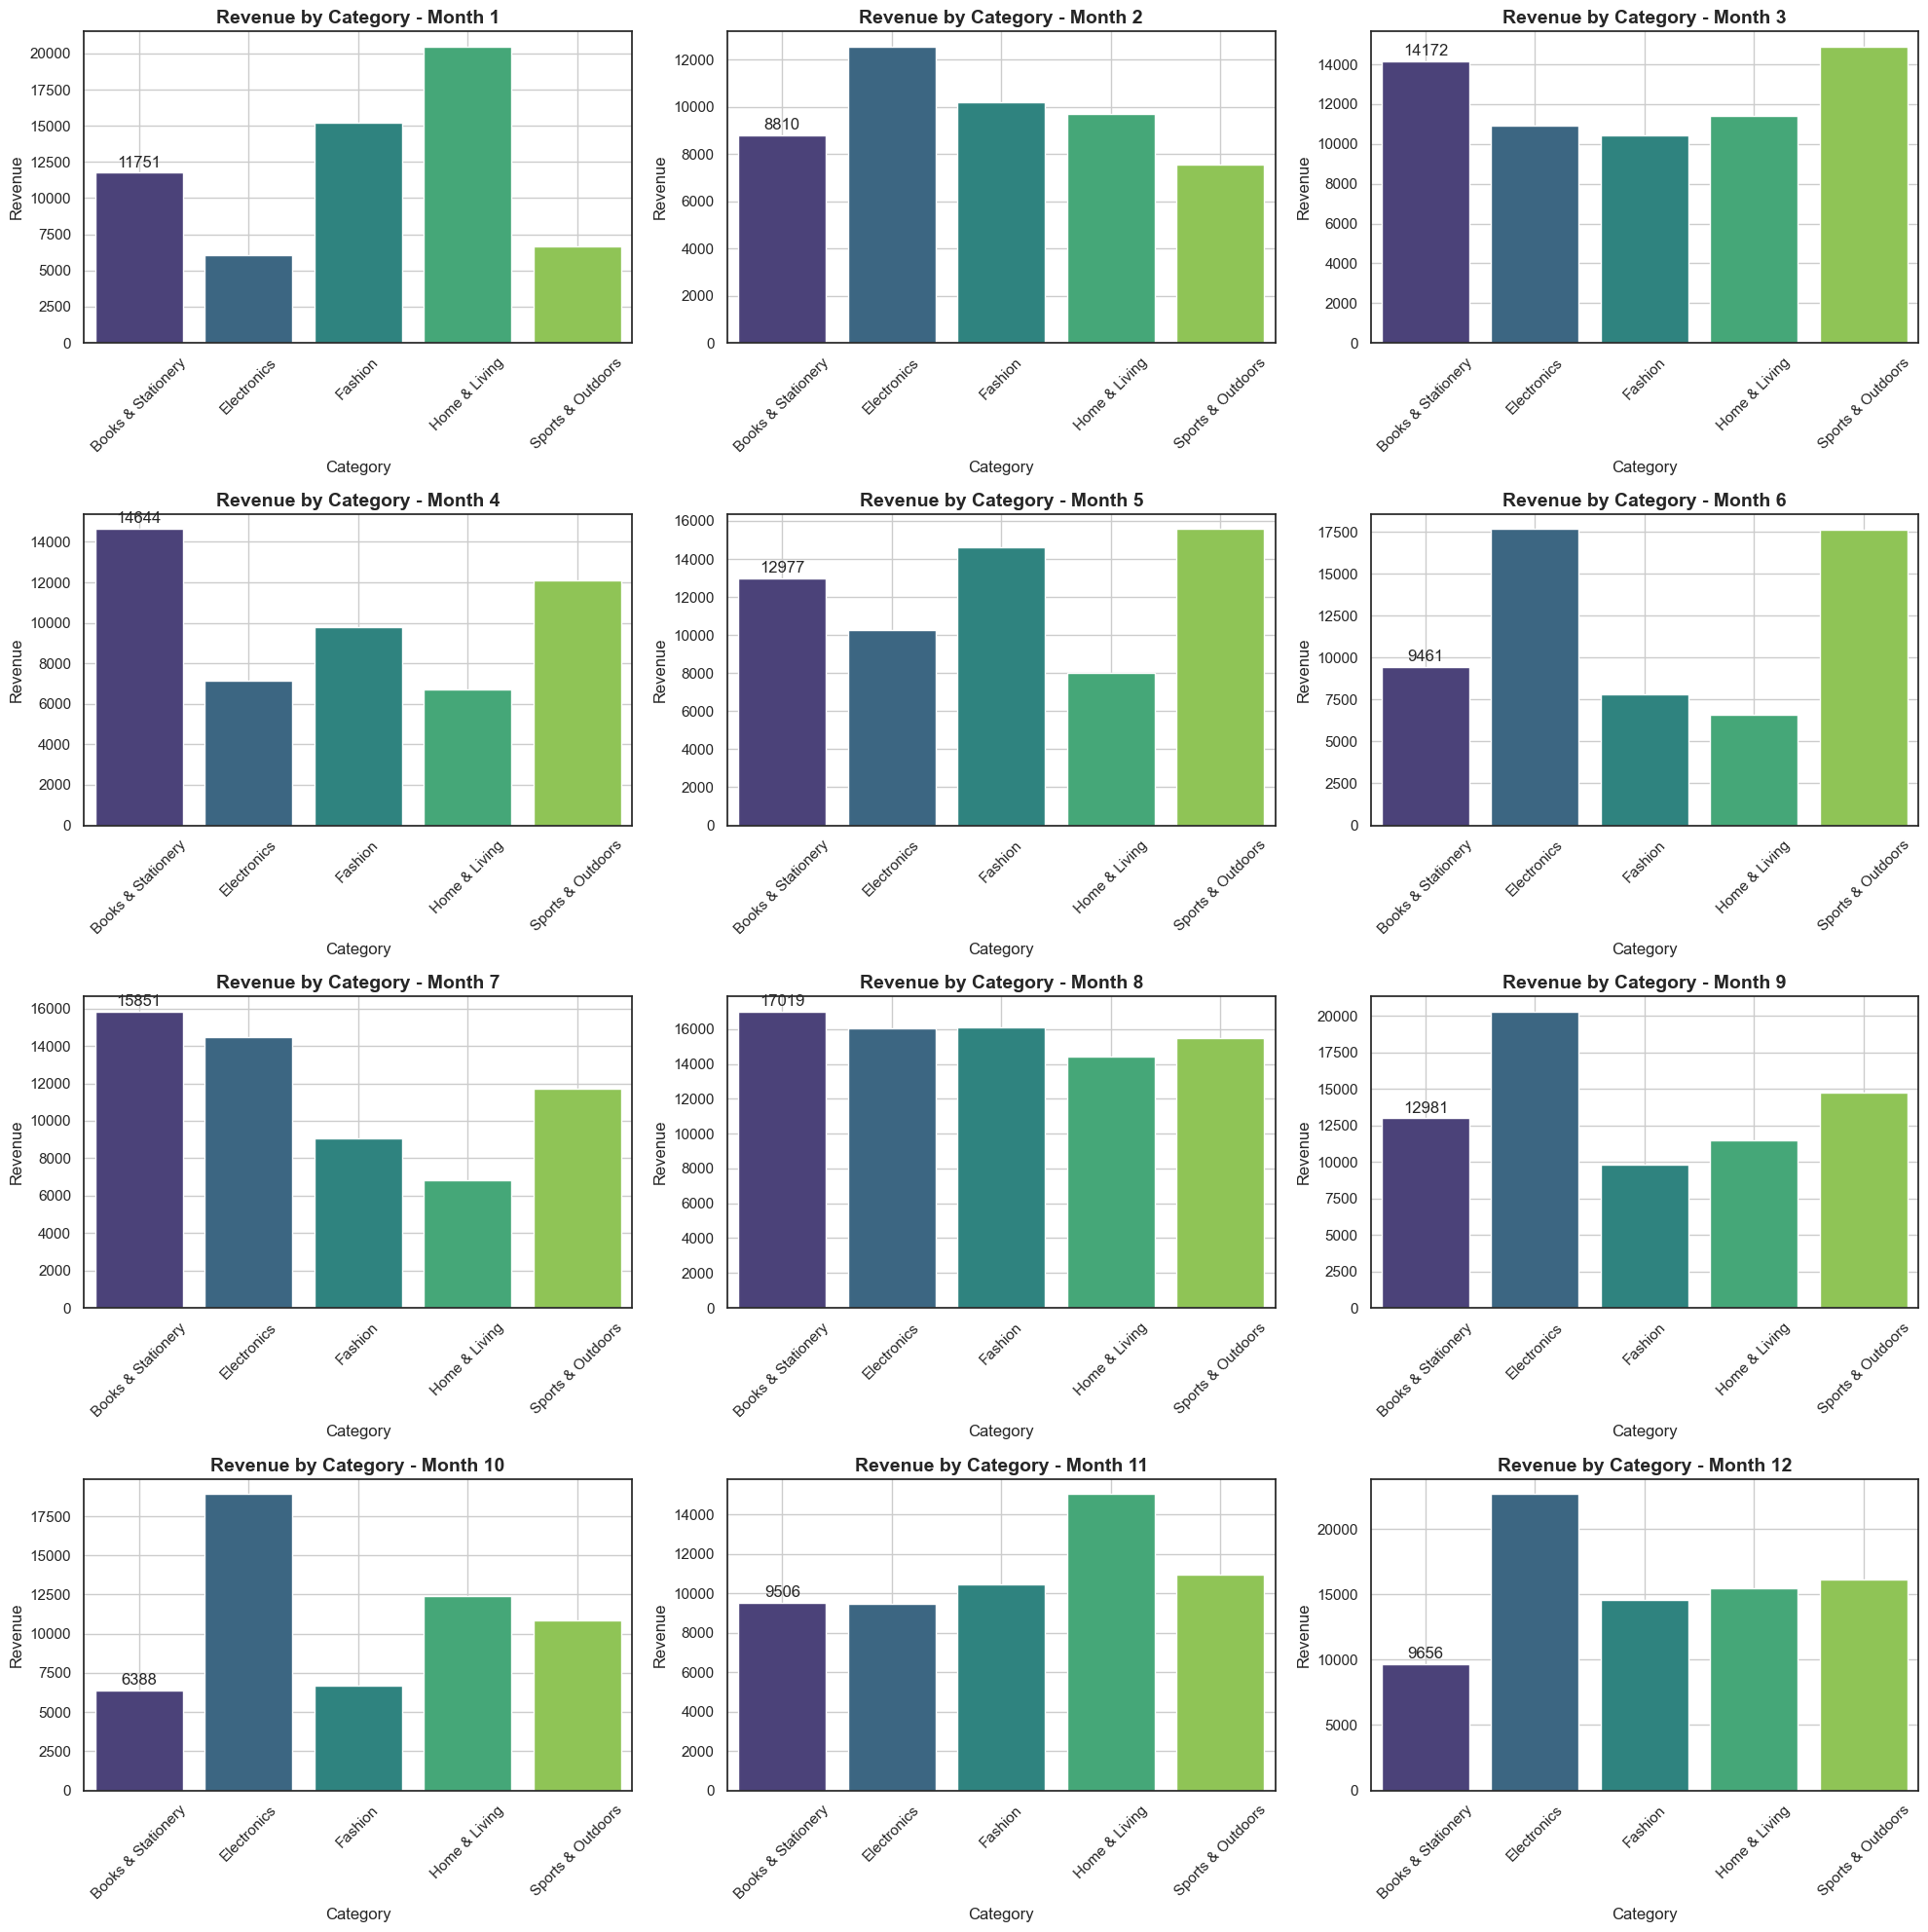

In [45]:
# Optional: Ensure 'Month' is integer
data['Month'] = data['Month'].astype(int)

# Get unique months (sorted)
months = sorted(data['Month'].unique())

# Set subplot layout - adjust based on number of months
rows = len(months) // 3 + (len(months) % 3 > 0)
fig, axes = plt.subplots(rows, 3, figsize=(20, rows * 5))
axes = axes.flatten()  # Flatten to easily iterate

for i, month in enumerate(months):
    # Filter data for the month
    month_data = data[data['Month'] == month]

    # Group by category and sum revenue
    category_revenue = month_data.groupby('category_name')['Revenue'].sum().reset_index()
    category_revenue = category_revenue.sort_values(by='Revenue', ascending=False)

    ax = axes[i]

    # Plot barplot
    sns.barplot(x='category_name', y='Revenue', data=category_revenue, ax=ax, palette='viridis')

    # Rotate x labels
    ax.tick_params(axis='x', rotation=45)

    # Add value labels on each bar
    ax.bar_label(ax.containers[0], fmt='%.0f', label_type='edge', padding=2)

    # Set titles and labels
    ax.set_title(f'Revenue by Category - Month {month}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Category', fontsize=12)
    ax.set_ylabel('Revenue', fontsize=12)
    ax.grid(True)

# Hide any extra subplots if months < axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


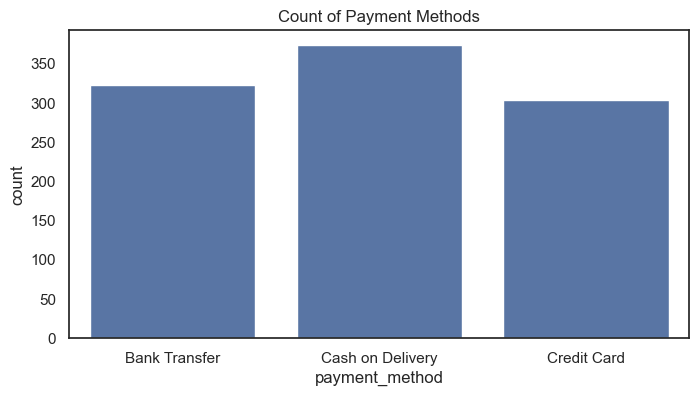

In [34]:
plt.figure(figsize=(8,4))
sns.countplot(x='payment_method', data=data)
plt.title('Count of Payment Methods')
plt.savefig('payment_method_count.png')
plt.show()


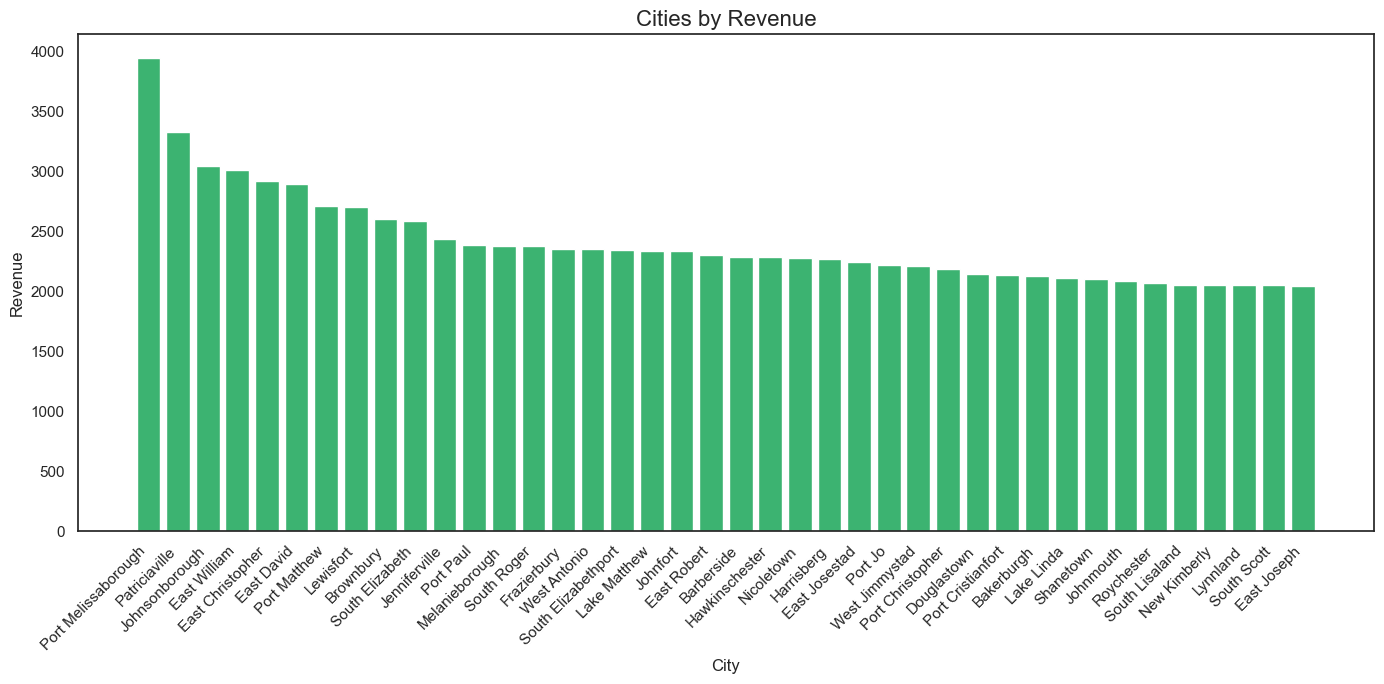

In [35]:
# Group by city and sum the revenue
city_revenue = data.groupby('city', as_index=False)['Revenue'].sum()

city_revenue = city_revenue.sort_values(by='Revenue', ascending=False)

top_cities = city_revenue.head(40)

plt.figure(figsize=(14, 7))
plt.bar(top_cities['city'], top_cities['Revenue'], color='mediumseagreen')
plt.xticks(rotation=45, ha='right')
plt.title('Cities by Revenue', fontsize=16)
plt.xlabel('City')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

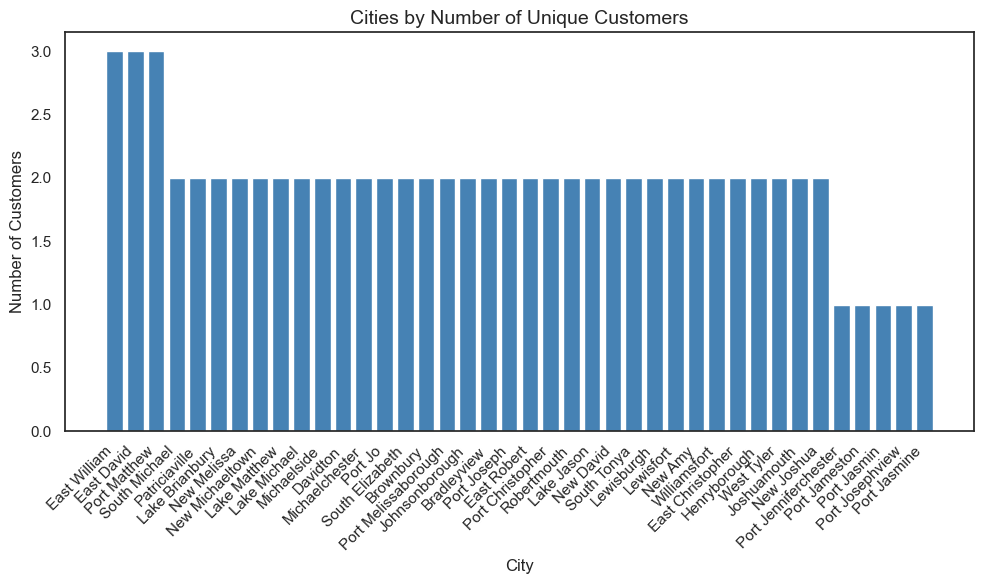

In [36]:

customers_by_city = data.groupby('city')['customer_id'].nunique().sort_values(ascending=False).head(40)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(customers_by_city.index, customers_by_city.values, color='steelblue')

plt.xticks(rotation=45, ha='right')
plt.title('Cities by Number of Unique Customers', fontsize=14)
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [37]:
correlation = df_numerical_col.dropna().corr()
correlation

,customer_id,product_id,category_id,quantity,price,review_score,age
customer_id,1.000000,0.046663,0.021508,-0.037232,0.048766,0.023883,0.061015
product_id,0.046663,1.000000,-0.034366,-0.018558,-0.016577,0.039664,-0.039283
category_id,0.021508,-0.034366,1.000000,-0.056989,-0.020829,0.024559,-0.021215
quantity,-0.037232,-0.018558,-0.056989,1.000000,-0.011864,0.037506,-0.035678
price,0.048766,-0.016577,-0.020829,-0.011864,1.000000,0.071454,0.025139
review_score,0.023883,0.039664,0.024559,0.037506,0.071454,1.000000,-0.003000
age,0.061015,-0.039283,-0.021215,-0.035678,0.025139,-0.003000,1.000000


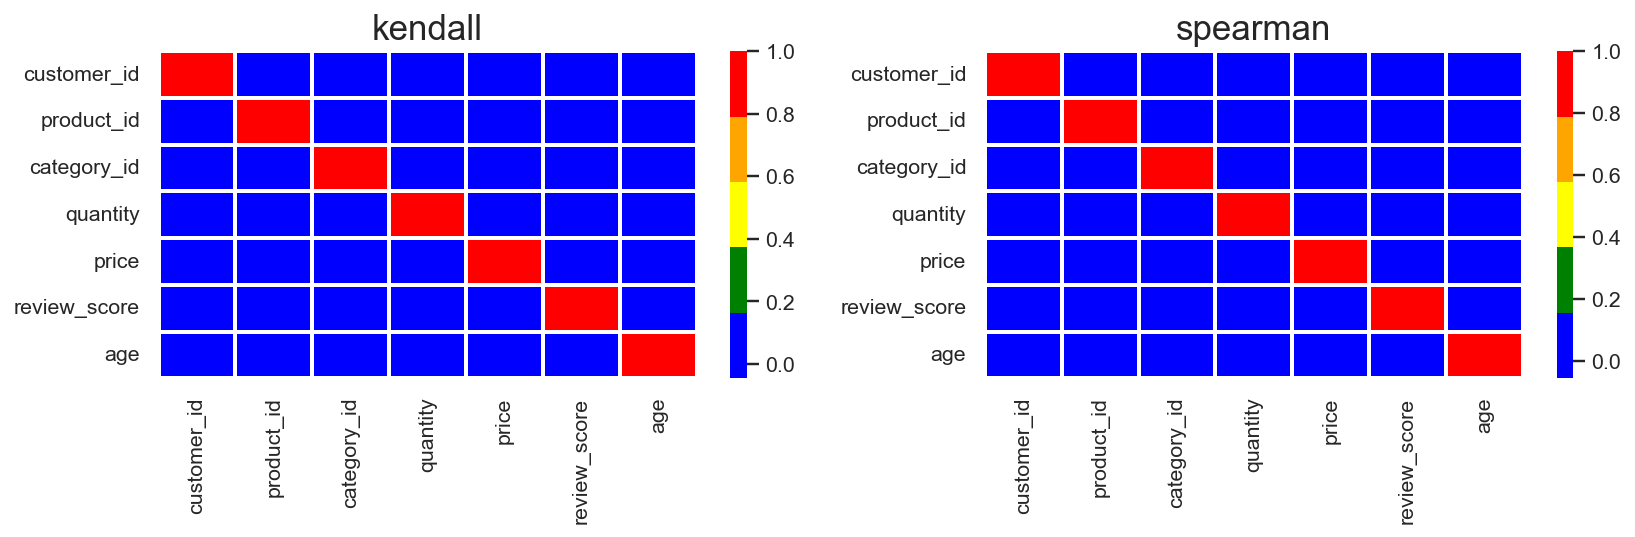

In [38]:
from matplotlib.colors import ListedColormap


plt.figure(figsize=(18,4), dpi=140)
for j , i  in enumerate(['kendall','spearman']):
    plt.subplot(1,3,j+1)
    cmap = ListedColormap(["blue", "green", "yellow", "orange", "red"])
    correlation = df_numerical_col.dropna().corr(method=i)
    sns.heatmap(correlation, linewidth = 2,cmap=cmap)
    plt.title(i, fontsize=18)

plt.tight_layout()
plt.show()